# **1. Unsupervised Learning Overview**

머신러닝의 학습 방법은 크게 지도 학습(supervised learning)과 비지도 학습(unsupervised learning)으로 나눌 수 있었다.
- 지도 학습 : 라벨링이 된 데이터를 학습시키는 것
- 비지도 학습 : 라벨링이 되지 않은 데이터를 학습시키는 것

여기서 라벨링이란, train data에 정답이 표시하는 작업을 지칭한다.
<br>

지금까진 입력-정답 쌍으로 구성된 데이터를 기반으로 지도 학습하는 방식의 머신러닝을 살펴보았으니 이번에는 레이블이 존재하지 않는, 즉 입력 값만 존재하는 데이터를 통해 학습하는 비지도 학습 방식에 대해 살펴보자.

<img src='https://la.mathworks.com/discovery/unsupervised-learning/_jcr_content/mainParsys/band/mainParsys/lockedsubnav_copy/mainParsys/columns/335ce30a-77fd-4c27-af75-93672733f56b/columns_1153932989/32c8f6b7-83fb-4bec-8db2-12f8633f26ca/image_2128876021_cop.adapt.full.medium.svg/1771578213610.svg' width='600' />

# **2. 군집화 (Clustering)**

<img src='https://la.mathworks.com/discovery/unsupervised-learning/_jcr_content/mainParsys/band/mainParsys/lockedsubnav_copy/mainParsys/columns/335ce30a-77fd-4c27-af75-93672733f56b/columns/0e1a10a0-b289-4f36-9928-f1add97647b8/image_2128876021_cop.adapt.full.medium.png/1771578213353.png' width='600' />

비지도학습의 가장 대표적인 학습 방법으로는 군집화가 있다. 군집(clustering)은 비슷한 샘플 데이터끼리 하나의 그룹으로 모으는 작업을 의미하며, 군집 알고리즘을 통해 형성된 그룹을 클러스터(cluster)라고 부른다. 이 과정에서 데이터셋의 자연스러운 그룹화 또는 내재된 구조를 이해할 수 있다.

대표적인 알고리즘으로는 K-means, K-Medians, Mean-Shift, DBSCAN 등이 있는데, 우리는 그중 K-means, Mean-Shift, DBSCAN에 대해 더 자세히 알아보자.

## **2-1. K-means**

클러스터 중심까지의 거리를 기준으로 데이터를 k개의 서로 다른 클러스터로 분할하는 방법이다.

### **알고리즘**


1. training sample에서 우리가 cluster의 개수만큼 클러스터 중심(cluster center)과 센트로이드(centroid)를 임의로 지정한다. <br/>(Random하게 K개의 센트로이드를 초기화한다.)

$$\mu_{1}, \mu_{2}, \cdots, \mu_{k} \in \mathbb{R}^{n}$$

2. 모든 training sample에 대해서 가장 가까운 센트로이드의 cluster로 할당한다. (cluster assignment step)

$$\min_{k}||x^{(i)}-\mu_{k}||^{2}$$

3. 각 cluster에 해당하는 모든 점들의 평균을 구하고, 그 평균으로 센트로이드를 옮긴다(갱신한다). (move centroid step)

$$\mu_{k}=\frac{1}{m}(x^{1}, \cdots, x^{i}, \cdots, x^{m})$$

4. 2번과 3번을 계속해서 반복하면, 센트로이드가 더 이상 움직이지 않고 수렴하는 지점에서 cluster가 결정된다.

<br>

**변수 설명:**
- $\mu_{k}$ : cluster k의 centriod 위치
- $k$ : cluster의 개수
- $\{x^{i}\}$ : 각 cluster에 있는 training set
- $m$ : 각 cluster에 있는 training set의 개수

<p float="left">
    <img src="https://datahacker.rs/wp-content/uploads/2020/07/K-means_convergence.gif" width="500" />
</p>

### **최적화**

K-means 알고리즘을 최적화하는 방법은 다음과 같다. 아래는 K-means 알고리즘의 비용함수다. (Distortion function이라고 부르기도 한다)

$$J(c^{(1)}, \cdots, c^{(m)}, \mu^{(1)}, \cdots, \mu^{(k)})=\frac{1}{m}\sum^{m}_{i=1}||x^{(i)}-\mu_{c^{(i)}}||^{2}$$

$$ \min_{c, \, \mu} J(c^{(1)}, \cdots, c^{(m)}, \mu^{(1)}, \cdots, \mu^{(k)})$$


**변수 설명:**
- $c^{(i)}$ : 각각의 training set($x^{i}$)이 할당되어 있는 cluster의 인덱스
- $\mu_{k}$ : cluster k의 centriod 위치
- $\mu_{c^{(i)}}$ : cluster의 인덱스($c^{(i)}$)의 centriod 위치

<br>

알고리즘의 최종 목적은 비용함수 J를 최소화하는 c와 $\mu$를 찾는 것이다.

+ 추가적으로 여러 번 랜덤 초기화(random initialization)을 통해 시행시켜 지역 최적점(local optima)에 빠지지 않고 전역적으로 가장 좋은 모델을 선택하는 것이 이상적이다.

### **최적 K 값 찾기**

cluster의 개수인 k 값은, 데이터를 직접 확인하거나 다른 clustering algorithm의 결과를 보고 수동으로 결정할 수 있다.

그 중에서 Elbow Method 는 k의 개수를 1에서 점차 늘려가면서 비용함수
(Distortion function)을 계산한다. x축을 k (cluster의 개수), y축을 비용함수로 설정하고 그래프를 그려보면, 특정 k 이후의 비용이 거의 변하지 않는 지점을 찾을 수 있다. 우리는 그곳을 elbow point라고 일컫고, 해당 지점을 k로 선택하는 것이 바람직하다.

<img src='https://miro.medium.com/v2/resize:fit:667/1*RN-pJyhZYa7l303XHRHrQQ.png
' height='320'/>


### **실습 예제**

<blockquote>

이번 실습에서는 K-means를 실제 데이터에 적용해보며 데이터가 어떻게 클러스터로 분리되는지를 확인해본다.

이를 위해 붓꽃(Iris) 데이터를 활용한다.
붓꽃 데이터는 꽃받침(sepal)과 꽃잎(petal)의 길이와 너비 정보를 포함하고 있으며,
세 가지 붓꽃 품종(Setosa, Versicolor, Virginica)으로 구성되어 있다.

실습을 통해 두 개의 feature (sepal length, sepal width)를 사용하여
데이터가 정말로 세 개의 군집으로 분리될 수 있는지 K-means 알고리즘을 통해 확인해보자 !

우선 dataset에서 DataFrame을 활용해 구조를 파악하고, feature, target variable을 설정한다.

※ *변수에 데이터가 어떻게 저장되어있는지 등 print해보고 싶은 부분이 생긴다면 아래 코드에 print문을 추가하여 꼭 확인해 보도록하자.*

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
x_data = iris.data[:, :2] #use only 'sepal length and sepal width' # 'sepal length (cm)''sepal width (cm)'
y_data = iris.target

In [3]:
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


In [5]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(x_data)

KMeans(n_clusters=3, random_state=42)

In [6]:
km.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

In [7]:
import numpy as np
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2], dtype=int32), array([47, 53, 50]))

`.transform` 메소드는 훈련 데이터 샘플에서 클러스터 중심까지 거리로 변환해준다.

In [8]:
km.transform(x_data)

array([[1.76483558, 1.05159358, 0.11840608],
       [1.91421501, 0.9261403 , 0.44093083],
       [2.11649197, 1.18751365, 0.38160189],
       [2.21291325, 1.24233499, 0.52193869],
       [1.88740674, 1.19250806, 0.17210462],
       [1.6362795 , 1.26401576, 0.61483331],
       [2.23658316, 1.37037386, 0.40696437],
       [1.84176313, 1.04835901, 0.02863564],
       [2.41906566, 1.38917649, 0.80375369],
       [1.91293635, 0.96397369, 0.34470277],
       [1.54505593, 1.07457758, 0.47876926],
       [2.03892075, 1.20353254, 0.2078942 ],
       [2.01414307, 1.02100579, 0.47499474],
       [2.51386918, 1.50533642, 0.82560281],
       [1.37197092, 1.30781396, 0.9785806 ],
       [1.73068857, 1.70913197, 1.19432826],
       [1.6362795 , 1.26401576, 0.61483331],
       [1.76483558, 1.05159358, 0.11840608],
       [1.32839928, 1.10998895, 0.78741349],
       [1.86009779, 1.2962937 , 0.38369259],
       [1.44978574, 0.80011792, 0.39499367],
       [1.82341915, 1.21196862, 0.28778464],
       [2.

`.predict` 메소드는 가장 가까운 centriod의 cluster로 출력한다.

In [9]:
y_predict = km.predict(x_data)
y_predict

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

KMeans는 반복적으로 클러스터 중심을 옮기면서 최적의 클러스터를 찾는데, `n_iter_` 메소드는 이 알고리즘이 반복한 횟수를 출력한다.

In [10]:
print(km.n_iter_)

8


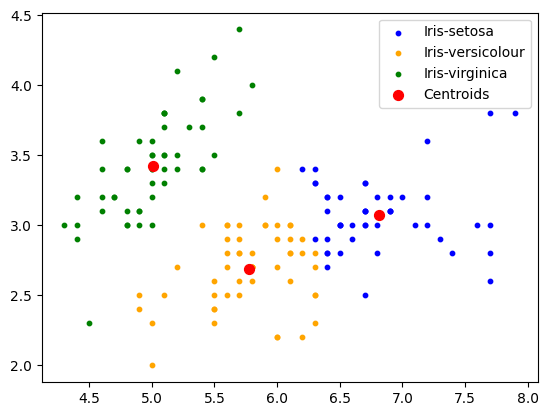

In [11]:
import matplotlib.pyplot as plt

#Visualising the clusters
plt.scatter(x_data[y_predict == 0, 0], x_data[y_predict == 0, 1], s = 10, c = 'blue', label = 'Iris-setosa')
plt.scatter(x_data[y_predict == 1, 0], x_data[y_predict == 1, 1], s = 10, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x_data[y_predict == 2, 0], x_data[y_predict == 2, 1], s = 10, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s = 50, c = 'red', label = 'Centroids')

plt.legend()

최적의 k를 찾기 위해서, Elbow method 를 진행해보자.

centriod와 샘플 사이의 거리의 제곱 합을 inertia라고 부르는데, inertia는 클러스터에 속한 샘플이 얼마나 가깝게 모여있는지를 나타낸다고 생각하면 된다. 일반적으로 클러스터 개수가 늘어나면 inertia도 줄어든다. KMeans에는 `inertia_` 메소드를 통해 Elbow method를 실행할 수 있다.

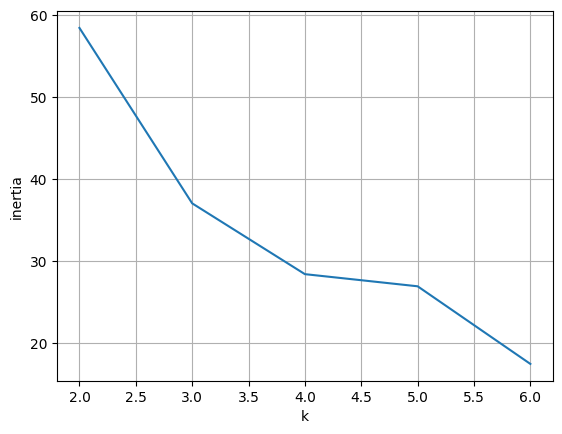

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_data)
    inertia.append(km.inertia_)
plt.plot(range(2, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.grid()
plt.show()

## **2-2. Mean-Shift Clustering**
데이터셋 내 데이터 포인트들의 평균값으로 탐색 창을 반복적으로 이동시켜 밀집 영역(모드)을 식별하는 비모수적 밀도 기반 클러스터링 알고리즘을 말한다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F2366BF4051930CE922' height='300'/>



### **Mean-Shift Clustering의 필요성**
여태까지, clustering이 무엇인지 이해하고 clustering의 가장 대표적이고 간단한 예시인 K-means에 대해 알아보았다. K-means 는 전체 N개의 데이터를 K개의 cluster로 빠르게 묶어낸다는 장점을 가지고 있지만, 두 가지의 한계점을 가지고 있다.
- cluster의 개수 K가 사전에 결정되어야 한다.
- 초기 중심점(Centroid) 설정에 따라 수렴 여부가 크게 좌우된다.

<br>

이와는 대조적으로, 시간이 좀 더 걸리더라도, 데이터에 따라 적절한 클러스터 개수 K를 발견하는 것부터 컴퓨터가 스스로 찾아내어 clustering 할 수 있다면 어떨까? 이러한 경우 비모수 기법 (nonparametric method) 방식을 사용할 수 있다. 이때 평균 이동(Mean-shift) clustering이 바로 대표적인 비모수 클러스터링 기법 알고리즘이다.  


#### **잠깐, 비모수 기법?**

여기서 모수적(parametric) 방법과 비모수적(nonparametric) 방법의 차이를 이해할 필요가 있다.
<br/>

- 모수: 데이터의 구조를 설명하기 위해 모델의 형태와 필요한 파라미터 수가 사전에 정해져 있는 방법. <br/>즉, 알고리즘이 동작하기 전에 사용자가 모델의 구조나 하이퍼파라미터를 미리 설정해야 한다.
- 비모수: 모델의 구조나 필요한 파라미터 수가 미리 고정되어 있지 않고, 데이터의 분포나 구조에 따라 모델이 유연하게 결정되는 방법.<br/> 사용자가 클러스터 개수와 같은 핵심 파라미터를 직접 지정하지 않더라도 스스로 구조를 찾아낸다.
<br/>
<div align="center">
<table style="border-collapse: collapse; text-align: center;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc; padding:8px;">구분</th>
      <th style="border:1px solid #ccc; padding:8px;">특징</th>
      <th style="border:1px solid #ccc; padding:8px;">예시</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ccc; padding:8px;">모수적 방법 (Parametric)</td>
      <td style="border:1px solid #ccc; padding:8px;">모델 구조와 파라미터 수가 사전에 결정됨</td>
      <td style="border:1px solid #ccc; padding:8px;">K-means</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:8px;">비모수적 방법 (Nonparametric)</td>
      <td style="border:1px solid #ccc; padding:8px;">데이터 구조에 따라 모델 복잡도가 결정됨</td>
      <td style="border:1px solid #ccc; padding:8px;">Mean-shift, DBSCAN</td>
    </tr>
  </tbody>
</table>
<br/>

<blockquote> 이제 K-means에서 Mean-Shift 로 이어지는 흐름이 어느정도 이해됐을 것이다. <br/>
본격적으로 Mean-Shift Clustering에 대해 공부해보자!

### **직관**

1. 'Mean-Shift Clustering의 필요성' 파트에서 Mean-Shift Clustering은 클러스터의 개수 k부터 스스로 찾는다고 했다. <br/>각 데이터마다 밀도가 높은 가까운 부분으로 이동하다보면 자연스레 데이터들이 모이는 지점들이 생길 것이고, 적절한 k가 보이기 시작할 것이다. 이를 토대로 클러스터를 형성할 수 있다. 그림과 함께 차근차근 살펴보자.  
<br/>

2. 데이터 x들이 아래와 같은 그래프를 형성하고 있다. 그중에서도 빨간 점들이 우리가 관측하고 있는 데이터들이라고 하자.  
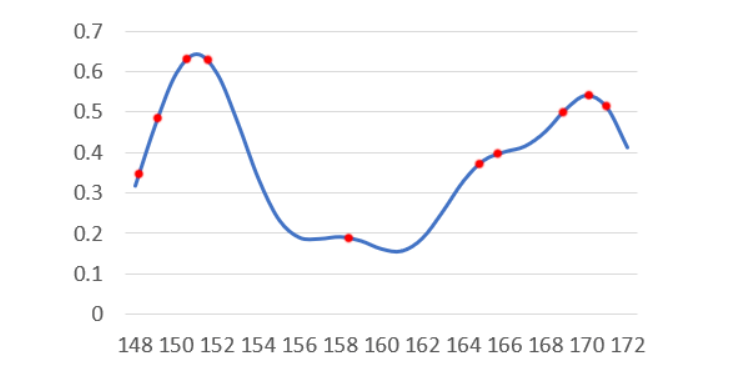
<br/>
<br/>

3. 빨간 점 데이터들 각각에 대하여 주변의 밀도를 계산하고, 밀도가 높은 쪽으로 조금씩 이동시킨다면, 아래 그래프에 표시된 것처럼 움직일 모습을 상상해볼 수 있다.  
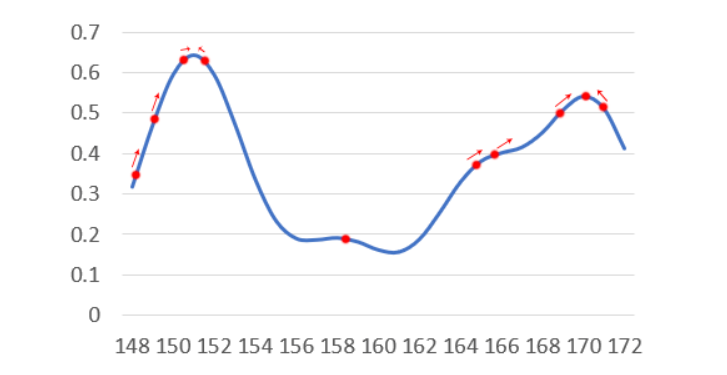
<br/>

4. 위 그래프 상에 나타낸 방향대로 점들이 움직이다보면, 왼쪽-중간-오른쪽 이렇게 총 3개의 클러스터가 형성될 것이라는게 이해될 것이다! <br/>이것이 바로 Mean-Shift clustering의 아이디어이다. <br/>
(실제로는 위 그래프에서 본 것처럼 연속적인 분포가 주어지지는 않고 점들만 주어지므로 이에 대한 계산 과정이 필요)

### **알고리즘**
<br/>
Mean-Shift 알고리즘은 다음과 같은 과정을 반복한다.

1. 각 데이터 포인트를 하나의 초기 중심점으로 설정한다.
2. 현재 중심점 주변에 반경 h (bandwidth)를 가지는 탐색 영역을 설정한다. 이 영역 안에 포함된 데이터들을 찾는다.
3. 탐색 영역 안에 있는 데이터들의 평균 위치를 계산한다. 계산된 평균 위치는 현재 위치보다 데이터 밀도가 높은 방향을 나타낸다.
4. 현재 중심점을 새로 계산된 평균 위치로 이동시킨다.
5. 중심점의 이동이 거의 없을 때까지 *[2-4]* 단계를 반복한다.
6. 같은 위치로 수렴한 중심점들을 하나의 cluster로 묶는다. 일련의 과정을 통해 클러스터 개수가 자동으로 결정된다.

#### **커널 밀도 추정, KDE**
이러한 Mean-Shift는 데이터 밀도를 계산하기 위해 KDE(Kernel Density Estimation)라는 방법을 사용한다.

KDE의 아이디어는 다음과 같다, 각 데이터 포인트 주변에 작은 확률 분포(커널)을 놓고, 이를 모두 합쳐서 전체 데이터 분포의 밀도를 추정한다는 것.

> 밀도? 추정? 커널? 이런 용어들은 처음에는 낯설게 느껴질 수도 있지만 하나씩 살펴보면 생각보다 어렵지만은 않다.


- 밀도: 어떤 위치 x에서, 그 주변에 데이터가 얼마나 많이 모여 있는지 나타내는 값. 지점 x=a에서의 함수값 f(a)로 표현할 수도 있다.
- 밀도  추정: 관측된 데이터(표본)의 분포를 통해, 원래 변수(모집단)의 확률 밀도(분포)를 추정하는 것. <br/> 현실에서는 데이터가 실제로 어떤 정답 확률 분포를 따르는지 정확히 파악할 수 없으므로, 이러한 추정 과정이 필요하다.
- 커널 함수: 각 데이터 포인트가 주변 공간에 얼마나 영향을 미치는지 나타내는 함수. <br/>원점을 중심으로 대칭이면서 적분값이 1인 non-negative 함수, 대체로 종 모양 형태 (ex: Gaussian, Uniform, etc) <br/> 실제 KDE에서는 Gaussian kernel이 가장 많이 사용된다.
    
  <img src="https://miro.medium.com/v2/resize:fit:1184/format:webp/1*EaNAnQMdYpe2haWiojM2ng.png" width=500>


- 커널 밀도 추정: Non-Parametric Density Estimation중의 한 방식으로 Kernel function을 이용하여 Histogram의 문제점을 개선한 밀도 추정 방식. <br/>
    > 각 데이터 $x_i$ 주변에 kernel 함수 $K$를 놓고, 그것을 모두 합쳐서 밀도를 추정.

  $$
  {KDE} = \frac{1}{n}\sum_{i=1}^{n} K_h(x - x_i)
            = \frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
  $$
    **변수 설명:**
    - $n$: 데이터 개수
    - $x_i$: i번째 데이터
    - $K$: kernel 함수
    - $h$: bandwidth (커널의 폭)

    > Histogram을 smoothing 했다고도 볼 수 있다. 히스토그램은 데이터의 확률 밀도를 추정하는 가장 간단한 방식이지만, <br/>discrete한 경계에서 불연속성을 가진다.
  



  **수행 절차:**
  
  이제 KDE 개념과 함께 좀 더 엄밀한 mean-shfit clustering 알고리즘을 다시 정리하자면,
  1. KDE를 이용해 데이터 공간의 확률 밀도를 추정한다.
  2. 각 데이터 포인트를 초기 중심으로 두고, 주변 데이터의 밀도를 계산하여 밀도가 증가하는 방향(gradient 방향)으로 중심을 이동시킨다.
  3. 이 과정을 반복하면 중심점은 데이터 밀도가 가장 높은 지점(mode)에 수렴할 수 있다.
  4. 동일한 mode로 수렴한 데이터 포인트들을 하나의 cluster로 묶는다.
  5. 이때 mode의 개수만큼 cluster가 형성되므로, 별도로 군집 개수를 지정할 필요가 없다.

      <img src="https://blog.kakaocdn.net/dna/dPtyZz/btruRLF9rfr/AAAAAAAAAAAAAAAAAAAAAIkBYUwGANX_2BcOyebKGFH6dwOfBkwE5sAAl5gUVWaa/img.gif?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=IQ0SDeGvwkr5xS6mXLEXF8o9brI%3D" width=500>

  **알고리즘의 장단점:**

    - 장점: K-Means 알고리즘과 대조적으로, 군집의 개수를 지정해 줄 필요가 없으며 평균이동 알고리즘이 알아서 군집의 개수를 알아낸다.
    - 단점: 탐색 창의 크기, 즉 bandwidth 크기 설정이 필요하다.

### **실습 예제**

<blockquote>

이번에는 밀도 기반 클러스터링 알고리즘인 Mean-shift가 데이터의 밀도 분포를 기반으로 어떻게 클러스터를 형성하는지 확인해보겠다.

실제 데이터 대신 `make_blobs` 함수를 이용하여
여러 개의 밀집된 데이터 군집을 가진 가상의 데이터를 생성하고,
Mean-shift 알고리즘을 적용하여 데이터의 밀도 중심(mode)을 찾아
클러스터가 형성되는 과정을 살펴본다.

또한 bandwidth 값을 변경하면서 클러스터 개수가 어떻게 변하는지도 확인한다.

먼저 필요한 라이브러리들을 import하자. 사이킷런은 Mean-Shift Clustering을 위해 MeanShift 클래스를 제공한다.

In [13]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

make_blobs 함수를 사용하여 가상 데이터셋을 생성해보자.

X에는 feature을, y에는 각 data point의 군집 label을 할당한다. MeanShift 클러스터링 알고리즘을 사용하여 데이터를 클러스터링한다.

In [14]:
X, y = make_blobs(n_samples=200, n_features=2, centers=3,
                  cluster_std=0.7, random_state=0)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)

bandwidth 값을 다르게 설정하여 클러스터링을 수행해보자.

In [15]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))  # 유형 출력해보기

[0 1 2]


estimate_bandwidth 함수를 통해 최적의 bandwidth 값을 추정해보자.

In [16]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print(round(bandwidth, 3))  # bandwidth 값

1.816


최적의 bandwidth를 사용하여 다시 클러스터링을 수행해보자.

In [17]:
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels)) # 유형 출력해보기

[0 1 2]


클러스터링 결과를 시각화해보자.

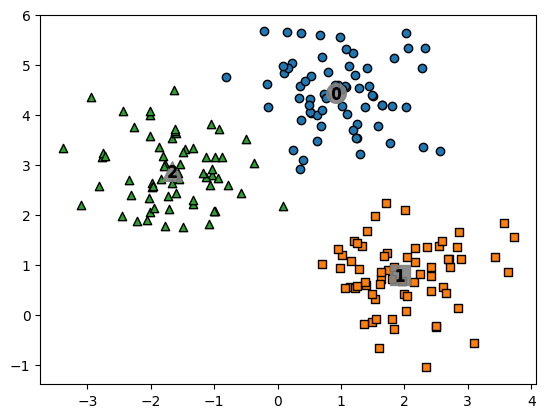

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label'] == label]
    center_x_y = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9, marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

In [19]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


## **2-3. DBSCAN**

DBSCAN은 Density-Based Spatial Clustering of Applications with Noise의 약자로, <br/>데이터가 밀집되어 있는 영역을 하나의 군집으로 간주하는 클러스터링 알고리즘이다.

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FIspJo%2FbtsGzoLBQgf%2FAAAAAAAAAAAAAAAAAAAAAPc0UGUZACp2-5gNYKgfu0o3dQsH7-nnoLEOycw8ny60%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DjwAcsXVWCMzVJi13Im1uboQo%252BzM%253D" height=250>

### **군집 알고리즘 분류**
지금까지 살펴본 클러스터링 알고리즘을 조금 더 넓은 관점에서 정리해보면 다음과 같이 분류할 수 있다.

계층적(Hierarchical) 방법과 비계층적(Non-hierarchical) 방법.


<br/>

이 중 비계층적 클러스터링은 데이터를 하나의 구조로 단계적으로 묶는 것이 아니라,
데이터의 특성을 기준으로 직접 클러스터를 형성하는 방법이다.

비계층적 클러스터링은 다시 클러스터를 형성하는 기준에 따라 다음과 같이 나눌 수 있는데,
- Distance-based : 데이터 간 거리(distance)를 기준으로 클러스터를 형성

- Density-based : 데이터가 얼마나 밀집되어 있는지(density)를 기준으로 클러스터를 형성

> 가장 처음 살펴봤던 K-means clustering은 대표적인 distance-based 알고리즘이다.<br/>
반면, Mean-shfit와 DBSCAN은 density-based 알고리즘에 속한다. <br/>
특히 DBSCAN은 밀도 낮은 데이터 포인트를 noise로 분류할 수 있다는 점이 큰 특징이다. 이러한 특성 덕분에 복잡한 형태의 데이터 분포에서도 효과적으로 클러스터를 찾을 수 있다.


<br/>


<table style="border-collapse: collapse; width: 100%; text-align: center; font-size: 14px;">
  <thead>
    <tr>
      <th style="border: 1px solid #ccc; padding: 8px;">항목</th>
      <th style="border: 1px solid #ccc; padding: 8px;">K-means</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Mean-shift</th>
      <th style="border: 1px solid #ccc; padding: 8px;">DBSCAN</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">기본 아이디어</td>
      <td style="border: 1px solid #ccc; padding: 8px;">클러스터 중심과의 거리를 기준으로 데이터를 묶음</td>
      <td style="border: 1px solid #ccc; padding: 8px;">데이터 밀도가 높은 방향으로 중심을 이동시켜 군집 형성</td>
      <td style="border: 1px solid #ccc; padding: 8px;">밀도가 높은 영역을 하나의 클러스터로 확장하며 군집 형성</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">분류 기준</td>
      <td style="border: 1px solid #ccc; padding: 8px;">Distance-based</td>
      <td style="border: 1px solid #ccc; padding: 8px;">Density-based</td>
      <td style="border: 1px solid #ccc; padding: 8px;">Density-based</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">클러스터 개수 K</td>
      <td style="border: 1px solid #ccc; padding: 8px;">사전에 지정해야 함</td>
      <td style="border: 1px solid #ccc; padding: 8px;">자동으로 결정됨</td>
      <td style="border: 1px solid #ccc; padding: 8px;">자동으로 결정됨</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">핵심 파라미터</td>
      <td style="border: 1px solid #ccc; padding: 8px;">클러스터 개수 K</td>
      <td style="border: 1px solid #ccc; padding: 8px;">Bandwidth (탐색 반경)</td>
      <td style="border: 1px solid #ccc; padding: 8px;">eps, min_samples</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">중심/군집 형성 방식</td>
      <td style="border: 1px solid #ccc; padding: 8px;">각 군집의 평균 위치로 중심 갱신</td>
      <td style="border: 1px solid #ccc; padding: 8px;">밀도 함수의 봉우리(mode)로 이동</td>
      <td style="border: 1px solid #ccc; padding: 8px;">핵심점(core point)을 기준으로 이웃 점들을 연결</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">이상치(Noise) 처리</td>
      <td style="border: 1px solid #ccc; padding: 8px;">별도 처리 어려움</td>
      <td style="border: 1px solid #ccc; padding: 8px;">명시적 noise 처리 없음</td>
      <td style="border: 1px solid #ccc; padding: 8px;">noise를 명시적으로 구분 가능</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">잘 맞는 데이터 형태</td>
      <td style="border: 1px solid #ccc; padding: 8px;">구형(spherical)이고 비교적 단순한 군집</td>
      <td style="border: 1px solid #ccc; padding: 8px;">밀도 봉우리가 뚜렷한 데이터</td>
      <td style="border: 1px solid #ccc; padding: 8px;">복잡한 모양의 군집, 이상치가 있는 데이터</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">장점</td>
      <td style="border: 1px solid #ccc; padding: 8px;">간단하고 빠름</td>
      <td style="border: 1px solid #ccc; padding: 8px;">K를 미리 정하지 않아도 됨</td>
      <td style="border: 1px solid #ccc; padding: 8px;">K가 필요 없고 noise 처리 가능</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px; font-weight: bold;">단점</td>
      <td style="border: 1px solid #ccc; padding: 8px;">K를 미리 정해야 하고 초기값에 민감함</td>
      <td style="border: 1px solid #ccc; padding: 8px;">계산량이 크고 bandwidth 선택이 중요함</td>
      <td style="border: 1px solid #ccc; padding: 8px;">eps와 min_samples 설정에 민감함</td>
    </tr>
  </tbody>
</table>

### **알고리즘**
DBSCAN의 기본 아이디어는 다음과 같다.
> 특정 점 주변에 충분한 개수의 이웃 데이터가 존재하면 그 점을 중심으로 클러스터를 확장하고,
이러한 과정을 반복하여 밀도가 높은 영역 전체를 하나의 클러스터로 형성한다.

**주요 개념:**

DBSCAN은 두 개의 중요한 파라미터를 사용한다.
- Eps (ϵ) : 한 점 주변에서 이웃을 탐색하는 반경
- MinPts : 군집 생성에 필요한 최소 데이터 포인트 수 (자기 자신도 포함)
  - MinPts = 4라면, 아래 이미지에서 Eps 내의 점이 5개이므로 이들을 하나의 군집으로 판단할 수 있다

    <img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F9930A63359E057BA1A' width='300'/>

이 두 기준 값을 이용하여 데이터 포인트를 다음 세 가지 유형으로 분류한다.
- core point : 설정한 반경(Eps) 안에 MinPts 개수 이상의 데이터 포인트(자기 자신 포함)가 존재하면, 그 점은 core point 가 된다.
- border point : 어떤 점이 core point는 아니지만, core point 의 반경 (Eps) 안에 놓이는 경우이다. <br/>(중심은 아니지만 군집에 속하는 점, 클러스터의 경계에 위치)
- noise point : core도 border도 아닌 점으로, 어떤 클러스터에도 속하지 않는다.

  | <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F996B8A3359E057BA27" height="200"/> | <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99D7893359E057B938" height="200"/> |
    |---|---|
    | Border Point (P2) | Noise Point (P4) |




step 별로 정리해보면 다음과 같이 동작한다.

1. 임의의 데이터 포인트를 선택한다.
2. 해당 점의 ε 반경 내 이웃 개수를 확인한다.
3. 이웃 개수가 Min_samples 이상이면 core point로 판단하고 클러스터를 생성한다.
4. core point와 density reachable한 점들을 계속 확장하여 클러스터를 형성한다.
5. 더 이상 확장할 수 없으면 새로운 점에서 다시 시작한다.
6. 어떤 클러스터에도 포함되지 않은 점들은 noise로 분류한다.


    <img src='https://blog.kakaocdn.net/dn/dbsrtM/btrCXSyvXm4/VbQ9LBnSzMeEifhGAnfdLK/img.gif
    ' width='500' height='350'/>

### **실습 예제**

<blockquote>

이번 실습에서는 DBSCAN을 사용하여 데이터의 밀집 영역을 기반으로 클러스터를 형성하는 과정을 살펴본다.

DBSCAN은 K-means와 달리 클러스터 개수를 사전에 지정할 필요가 없으며,
최소 데이터 개수를 기반으로 밀도가 낮은 포인트를 noise(이상치)로 구분할 수 있다는 특징을 가진다.

이번 실습에서는 (K-means 실습에서도 사용했던) 붓꽃(Iris) 데이터의 feature를 사용해 DBSCAN 알고리즘이 데이터의 밀도 구조를 기반으로 클러스터를 형성하는 방식을 실제로 확인해보려고 한다.

바로 iris dataframe 생성해보자.

In [20]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
labels = pd.DataFrame(iris.target)
labels.columns=['labels']
data = pd.DataFrame(iris.data)
data.columns=['Sepal length','Sepal width','Petal length','Petal width']
data = pd.concat([data,labels],axis=1)
feature = data[ ['Sepal length','Sepal width','Petal length','Petal width']]
feature.head()

,Sepal length,Sepal width,Petal length,Petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [21]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot  as plt
import seaborn as sns

# create model and prediction
model = DBSCAN(eps=0.5,min_samples=5)
predict = pd.DataFrame(model.fit_predict(feature))
predict.columns=['predict']

# concatenate labels to df as a new column
r = pd.concat([feature,predict],axis=1)

print(r)

     Sepal length  Sepal width  Petal length  Petal width  predict
0             5.1          3.5           1.4          0.2        0
1             4.9          3.0           1.4          0.2        0
2             4.7          3.2           1.3          0.2        0
3             4.6          3.1           1.5          0.2        0
4             5.0          3.6           1.4          0.2        0
..            ...          ...           ...          ...      ...
145           6.7          3.0           5.2          2.3        1
146           6.3          2.5           5.0          1.9        1
147           6.5          3.0           5.2          2.0        1
148           6.2          3.4           5.4          2.3        1
149           5.9          3.0           5.1          1.8        1

[150 rows x 5 columns]


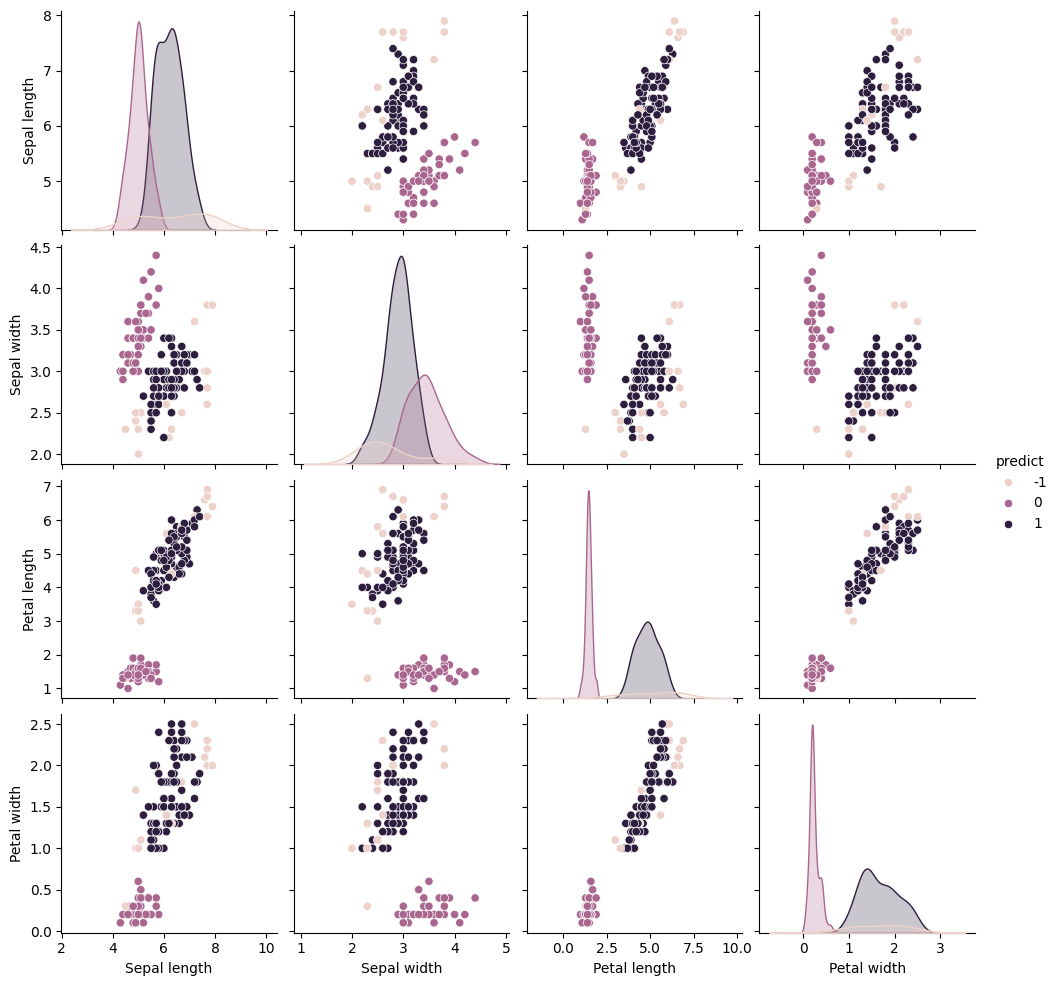

In [22]:
#sns 라이브러리의 pairplot으로 표현
sns.pairplot(r,hue='predict')
plt.show()

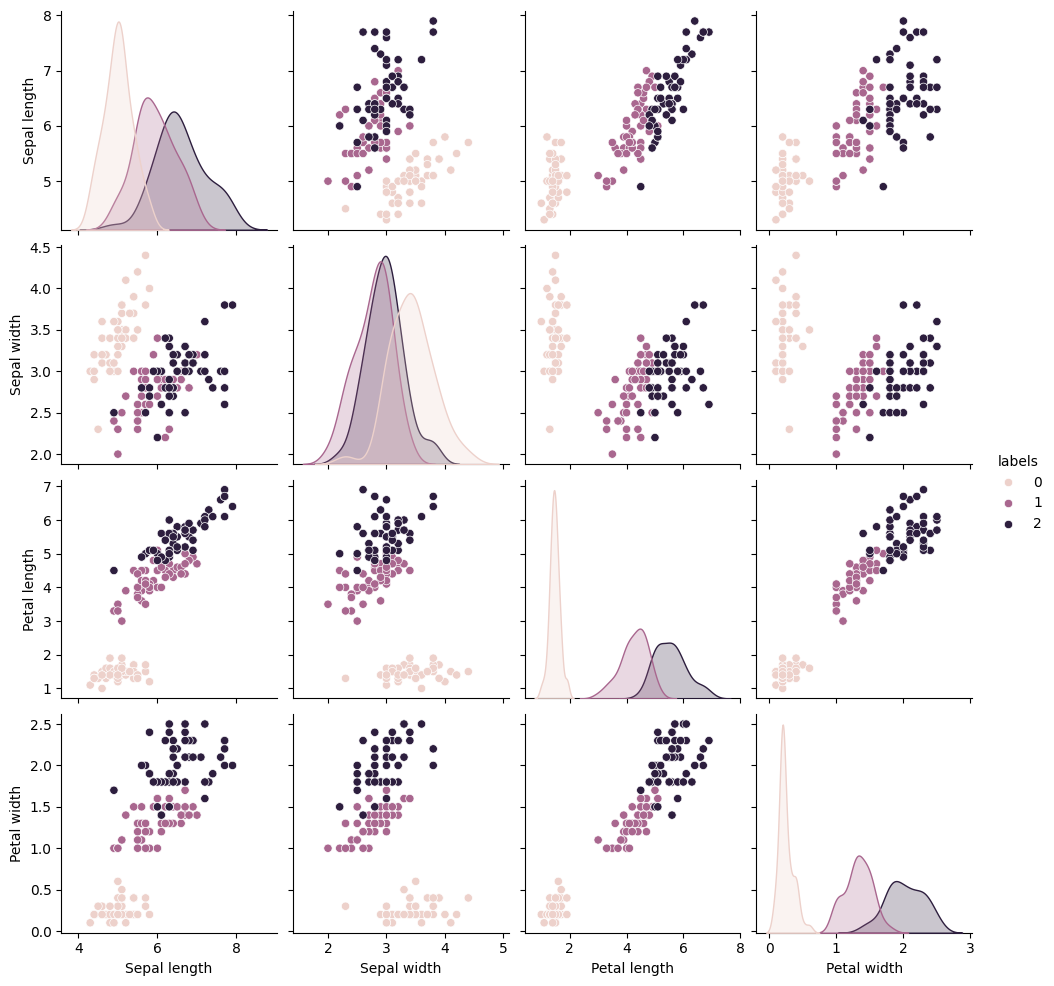

In [23]:
#sns 라이브러리의 pairplot으로 표현
sns.pairplot(data,hue='labels')
plt.show()

# **3. 차원 축소 (Dimensionality Reduction)**

지금까지 살펴본 K-means, Mean-shift, DBSCAN 알고리즘은 <br>
데이터를 유사한 그룹으로 나누는 군집화(clustering) 방법이었다.

<br/>

하지만 실제 데이터 분석에서는 다음과 같은 문제가 자주 발생한다.

- 데이터의 feature 개수가 매우 많은 경우

- 변수 간 상관관계가 강한 경우

- 고차원 데이터로 인해 분석 및 시각화가 어려운 경우
<br>

이러한 요인들로 데이터의 구조를 이해하기 어려워지고 분석 비용도 증가할 때 문제롤 해소하기 위해 사용하는 대표적인 방법이 바로 차원 축소 이다.


<img src="https://www.sc-best-practices.org/_images/dimensionality_reduction.jpeg" height=200>


대표적인 차원 축소 방법에는 PCA, t-SNE, UMAP 같은 알고리즘들이 존재하지만, 우선 가장 기본적이고 널리 사용되는 PCA에 대해 자세히 학습해보자.

## **3-1. 주성분 분석, PCA (Principal component analysis)**

PCA는 고차원 데이터를 더 낮은 차원의 공간으로 변환하는
대표적인 차원 축소 알고리즘으로,

변수들을 선형 결합(linear combination) 하여
주성분(Principal Components) 이라는 새로운 변수를 생성한다.

<br>

이때 생성되는 주성분은 다음과 같은 특징을 가진다.

- 서로 직교(orthogonal) 하며 상관관계가 없음

- 데이터의 분산(variance)이 최대가 되는 방향을 찾음

### **직관**

2차원 데이터가 다음과 같이 분포되어 있다고 가정해보자.
```
feature1  →  x축
feature2  →  y축
```
데이터가 대각선 방향으로 퍼져 있다면,
x축과 y축을 그대로 사용하는 것보다

데이터가 퍼져있는 방향으로 새로운 축을 만드는 것이
데이터의 구조를 더 잘 설명할 수 있다.

<br>

PCA는 바로 이 데이터 분산이 가장 큰 방향을 찾아
새로운 좌표축으로 사용하는 방법이다.


```
PC1 : 데이터 분산이 가장 큰 방향
PC2 : PC1과 직교하면서 두 번째로 큰 분산 방향
```
이렇게 PC1, PC2를 이용하면
고차원 데이터를 더 적은 차원으로 표현할 수 있다.

<img src="https://miro.medium.com/1*37a_i1t1tDxDYT3ZI6Yn8w.gif" height=280>

### **알고리즘**


PCA는 다음과 같은 절차로 수행된다.

1. 평균을 빼고 표준편차로 나눔으로써, 데이터의 평균을 0으로 맞추어 표준화한다 (mean centering)
2. 표준화된 데이터를 이용하여 feature 간 관계를 나타내는 공분산 행렬($C$, covariance matrix) 계산한다. <br> 공분산 행렬은 변수들이 서로 어떤 방향으로 함께 변하는지를 나타낸다.
3. 공분산 행렬의 고유값(eigenvalue)과 고유벡터(eigenvector) 계산한다. <br> 이때 고유벡터는 데이터가 가장 크게 분산되는 방향을 나타낸다.
4. 계산된 고유벡터들을 하나의 행렬로 구성하여 데이터에 적용한다. <br>
이 과정에서 데이터는 새로운 좌표축으로 회전(rotation)되고 스케일이 조정된다.


    <img src="https://towardsdatascience.com/wp-content/uploads/2021/09/10xDAg3EkUb7yBKabSThfCA.gif">


4. 고유값이 큰 순서대로 주성분을 정렬한다.<br>
가장 큰 고유값을 가지는 고유벡터가 첫 번째 주성분(PC1) 이며, 이는 데이터의 분산을 가장 많이 설명하는 방향이다.


    <img src="https://towardsdatascience.com/wp-content/uploads/2021/09/1e_kBZQz2hsa7de6TxpgJqg.gif">

5. 상위 k개의 주성분을 선택하고 데이터를 해당 축으로 투영한다.<br> 이러한 방식으로 중요한 정보는 유지하면서 데이터의 차원을 줄일 수 있다. <br><br> 보통 $k << n$ 이다. (n은 시작 차원 크기, 원본 특징 개수)

    <br/>

    ※ *PCA는 선형대수학과 밀접하게 관련된 알고리즘이므로, 수식적인 유도나 이론적 배경을 보다 엄밀히 이해하고 싶다면 관련 서적이나 [참고 자료](https://towardsdatascience.com/eigenvalues-and-eigenvectors-378e851bf372/)를 통해 추가로 학습해보기를 권한다.*

<br/>

**알고리즘의 장단점:**

- 장점
  - 데이터 차원을 효과적으로 축소 가능
  - 데이터 시각화에 유용
  - 변수 간 상관관계를 제거
  - 계산 비용 감소

- 단점
  - 선형 관계만 모델링 가능
  - 변수 스케일에 민감
  - 해석이 어려울 수 있음
  - 이상치(outlier)에 영향을 받을 수 있음

### **Clustering과 PCA**

PCA와 clustering은 모두 비지도 학습에 속하지만
서로 다른 목적을 가진다.


| 구분 | PCA            | Clustering       |
| -- | -------------- | ---------------- |
| 목적 | 차원 축소          | 데이터 그룹화          |
| 결과 | 새로운 feature 생성 | cluster label 생성 |
| 예시 | PCA            | K-means, DBSCAN  |


### **실습 예제**

<blockquote>

이번 실습에서는 PCA를 이용하여 고차원 데이터를
저차원으로 변환하는 과정을 확인해본다. 마찬가지로 붓꽃 데이터를 활용한다.

이번에는 총 4개의 feature (sepal length, sepal width, petal length, petal width) 를 모두 사용하여 PCA를 통해 4차원 데이터 → 2차원 데이터로 변환하고, 데이터가 어떻게 분포하는지 시각화해보자.

In [23]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
# print(iris.keys())
print(f"feature ({len(iris.feature_names)}) :", iris.feature_names)
print(f" target ({len(iris.target_names)}) :", iris.target_names)

feature (4) : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
 target (3) : ['setosa' 'versicolor' 'virginica']


In [24]:
X = iris.data
y = iris.target

print(X.size)
print(y.size)

600
150


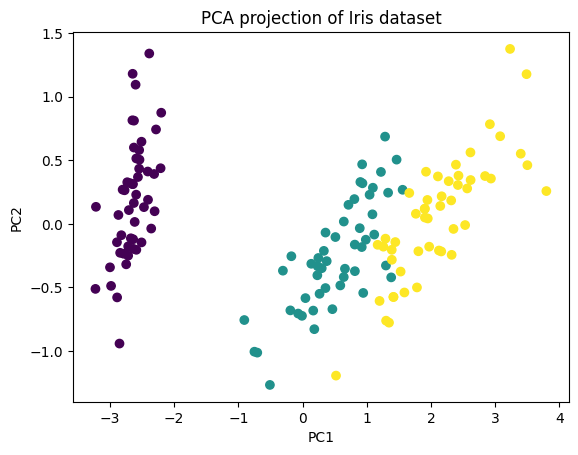

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of Iris dataset")
plt.show()

> 원래 4차원 feature 공간에 존재하는 데이터가
2차원 공간으로 변환된 모습을 확인할 수 있다 !

<br>

이렇게 변환된 데이터는

- 데이터 구조를 시각적으로 이해하기 쉽고
- 이후 clustering 알고리즘을 적용하기에도 유리하다.